## Business Problem

Telecom companies lose a significant number of customers every year due to churn.
Acquiring a new customer costs much more than retaining an existing one.

The objective of this project is to:

1. Predict whether a customer will churn
2. Identify the key factors that influence churn
3. Provide actionable business insights to reduce customer churn


# Telco Customer Churn: End-to-End ML Pipeline

**Context:** This notebook walks through a production-style workflow: data understanding, cleaning, exploration, feature engineering, modeling, evaluation, serialization, and probability-based scoring. Reusable logic lives in the `src/` package.

**Dataset:** IBM Telco Customer Churn (tabular, one row per customer, binary churn label).

**Pipeline overview**
1. **Preprocess** Fix types, handle invalid values, deduplicate, persist a clean table.
2. **Explore** Visualize relationships between churn and contract, tenure, charges, and related fields.
3. **Engineer features** Tenure bins, service uptake, derived spend metrics.
4. **Model** Scale and one-hot encode, train or test split, baseline logistic regression, compare algorithms, interpret coefficients.
5. **Deploy** Save fitted pipelines and score rows with **churn probability** (not only yes or no labels).

**Reproducibility:** Run cells top to bottom from the `notebooks/` directory. The persist section saves artifacts under `models/`; the following section loads the best model per `metrics.json`.


## Environment setup

I import **pandas** and **NumPy** for data, **matplotlib** and **seaborn** for plots, and **scikit-learn** metrics for evaluation. The project root is added to `sys.path` so I can import **`src.*`** as a package, similar to a real repo where the notebook orchestrates and `src/` holds library code.

**Why separate `src/`?** The same preprocessing and training functions can be reused from notebooks, tests, or a batch job (`python -m src.train_model`) without duplicating code.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (8, 4)

from src.data_preprocessing import (
    CLEANED_CSV,
    RAW_DATA,
    clean_dataframe,
    load_cleaned_data,
    load_raw_data,
    save_cleaned_data,
)
from src.feature_engineering import (
    SERVICE_COLUMNS,
    add_derived_charges_features,
    add_tenure_group,
    encode_service_columns,
    prepare_modeling_xy,
)
from src.predict import load_pipeline, predict_proba_churn
from src.train_model import (
    build_preprocessor,
    compare_models,
    get_feature_names_after_preprocessing,
    logistic_regression_pipeline,
    train_and_save_pipelines,
    train_test_prepare,
)
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)


## 1. Data loading and preprocessing

**Goals:** (1) Confirm the raw file loads and matches expectations. (2) **Clean** data so models see numeric columns where appropriate, no rows with missing targets, no duplicate records, and no customer identifier in the feature matrix later.

**Why it matters:** `TotalCharges` is sometimes stored as text; coercing to numeric and dropping rows with missing charges avoids silent errors. **`customerID`** is not a causal feature: it would leak identity-like information and does not generalize, so I remove it before modeling. **Duplicates** would overweight the same customer.

The helper **`clean_dataframe()`** in `src.data_preprocessing` encodes these rules in one place; I call it after a quick profile of the raw table.


In [2]:
df = load_raw_data(RAW_DATA)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(f"The dataset contains {df.shape[0]} rows and {df.shape[1]} columns.")
df.info()


The dataset contains 7043 rows and 21 columns.
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  Paperl

In [4]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df["Churn"].value_counts()


Churn
No     5174
Yes    1869
Name: count, dtype: int64

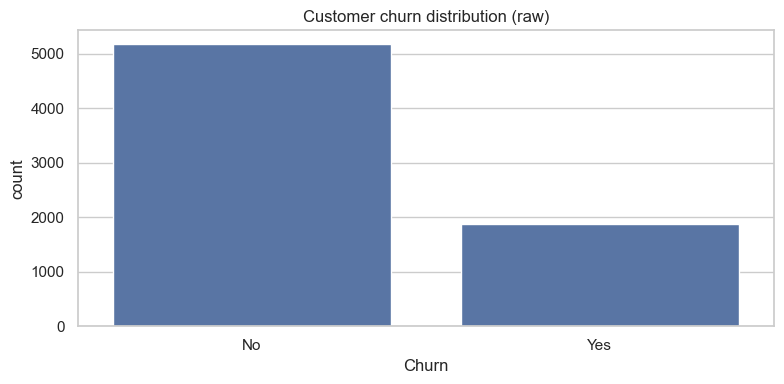

In [7]:
sns.countplot(x="Churn", data=df)
plt.title("Customer churn distribution (raw)")
plt.tight_layout()
plt.show()


### Apply `clean_dataframe()` (`src.data_preprocessing`)


In [8]:
df = clean_dataframe(df)
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7010 entries, 0 to 7009
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   str    
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   str    
 3   Dependents        7010 non-null   str    
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   str    
 6   MultipleLines     7010 non-null   str    
 7   InternetService   7010 non-null   str    
 8   OnlineSecurity    7010 non-null   str    
 9   OnlineBackup      7010 non-null   str    
 10  DeviceProtection  7010 non-null   str    
 11  TechSupport       7010 non-null   str    
 12  StreamingTV       7010 non-null   str    
 13  StreamingMovies   7010 non-null   str    
 14  Contract          7010 non-null   str    
 15  PaperlessBilling  7010 non-null   str    
 16  PaymentMethod     7010 non-null   str    
 17  Monthl

### Apply cleaning and persist

After cleaning, I **save** a CSV under `data/processed/` so EDA and later sessions can start from a **single source of truth** without re-running raw ingestion.


In [9]:
save_cleaned_data(df, CLEANED_CSV)
print(f"Saved cleaned data to {CLEANED_CSV}")


Saved cleaned data to D:\customer-churn-prediction\data\processed\cleaned_telco_churn.csv


## 2. Exploratory data analysis (EDA)

**Purpose:** Build intuition before modeling: **class balance**, and whether churn differs by **contract length**, **tenure**, **monthly bill**, **internet product**, and **payment method**.

**What to look for**
- **Imbalance:** If churn is rare or very common, accuracy alone can mislead; I still report precision, recall, and ROC-AUC.
- **Segmentation:** If month-to-month or fiber customers churn more, the model can learn those patterns; plots support stakeholder communication.

I **reload** the cleaned CSV here to mirror a fresh analysis session (same as loading in production from a known path).


In [10]:
df = load_cleaned_data(CLEANED_CSV)
df["Churn"].value_counts()


Churn
No     5153
Yes    1857
Name: count, dtype: int64

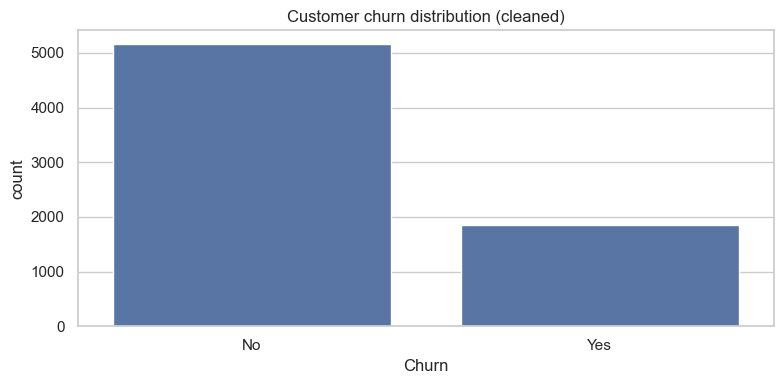

In [11]:
sns.countplot(x="Churn", data=df)
plt.title("Customer churn distribution (cleaned)")
plt.tight_layout()
plt.show()


In [12]:
df["Churn"].value_counts(normalize=True) * 100


Churn
No     73.509272
Yes    26.490728
Name: proportion, dtype: float64

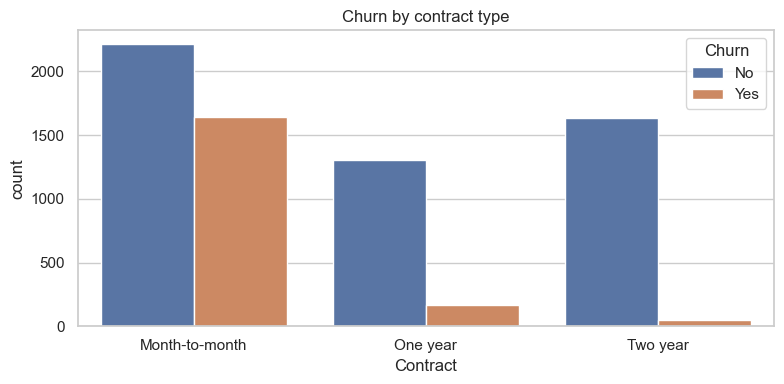

In [13]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.title("Churn by contract type")
plt.tight_layout()
plt.show()


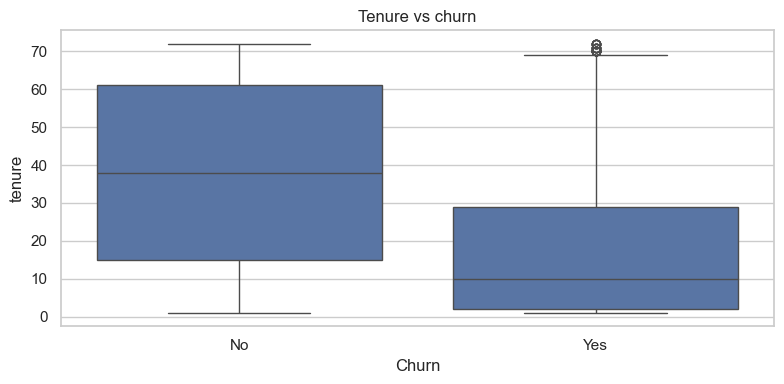

In [14]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs churn")
plt.tight_layout()
plt.show()


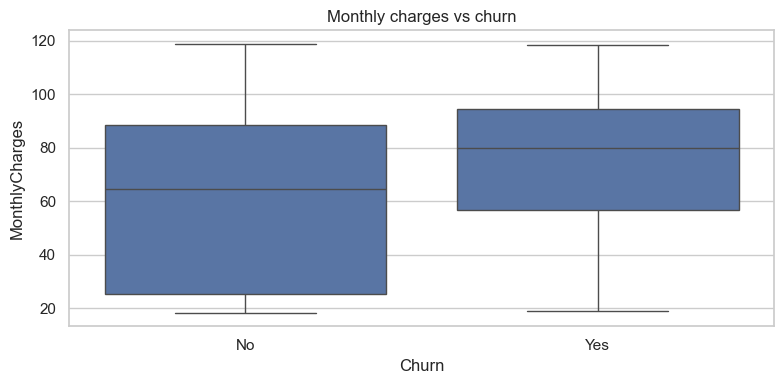

In [15]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly charges vs churn")
plt.tight_layout()
plt.show()


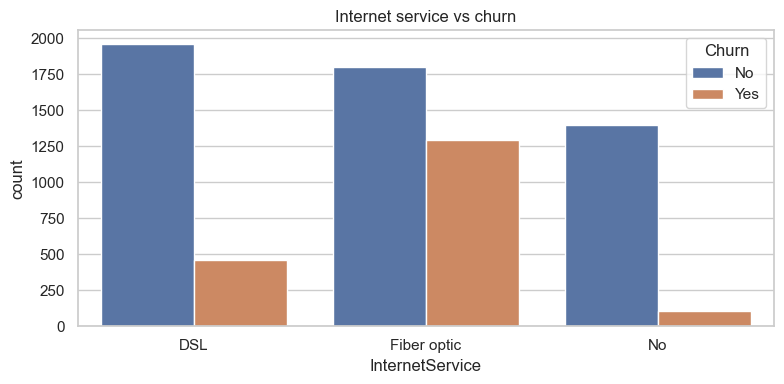

In [16]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet service vs churn")
plt.tight_layout()
plt.show()


In [17]:
df["PaymentMethod"].value_counts()


PaymentMethod
Electronic check             2359
Mailed check                 1588
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

## 3. Feature engineering

**Rationale:** Raw columns are a start, but **domain-informed** features often improve signal and interpretability.

| Step | Idea |
|------|------|
| **Tenure groups** | Early tenure often correlates with higher churn; bins capture non-linear effects. |
| **Binary service flags** | Yes or No add-ons become 0 or 1 for counting and for linear models. |
| **TotalServices** | Single summary of product depth. |
| **AvgMonthlySpend** | Approximate spend per month lived (`TotalCharges / tenure`, tenure 0 guarded) to capture billing dynamics. |

Implementation matches **`engineer_features()`** in `src/feature_engineering.py` (same steps, called here explicitly for transparency).


In [18]:
df = add_tenure_group(df)
df["tenure_group"].value_counts()


tenure_group
48-72    2239
0-12     2153
24-48    1594
12-24    1024
Name: count, dtype: int64

In [19]:
df["OnlineSecurity"].unique()
df["PhoneService"].unique()


<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [20]:
df = encode_service_columns(df)
df.dtypes
df[SERVICE_COLUMNS].sum()


PhoneService        6330
MultipleLines       2967
OnlineSecurity      2015
OnlineBackup        2425
DeviceProtection    2418
TechSupport         2040
StreamingTV         2703
StreamingMovies     2731
dtype: int64

In [21]:
df = add_derived_charges_features(df)
df["TotalServices"].describe()


count    7010.000000
mean        3.370756
std         2.061039
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max         8.000000
Name: TotalServices, dtype: float64

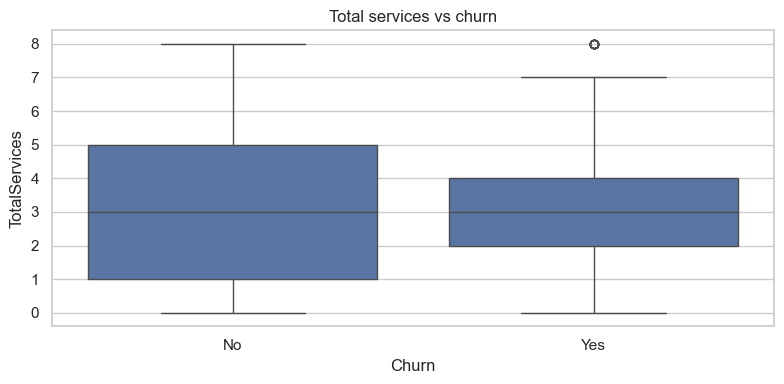

In [22]:
sns.boxplot(x="Churn", y="TotalServices", data=df)
plt.title("Total services vs churn")
plt.tight_layout()
plt.show()


In [23]:
df["AvgMonthlySpend"].describe()


count    7010.000000
mean       64.889885
std        30.165065
min        13.775000
25%        36.460119
50%        70.498684
75%        90.256548
max       121.400000
Name: AvgMonthlySpend, dtype: float64

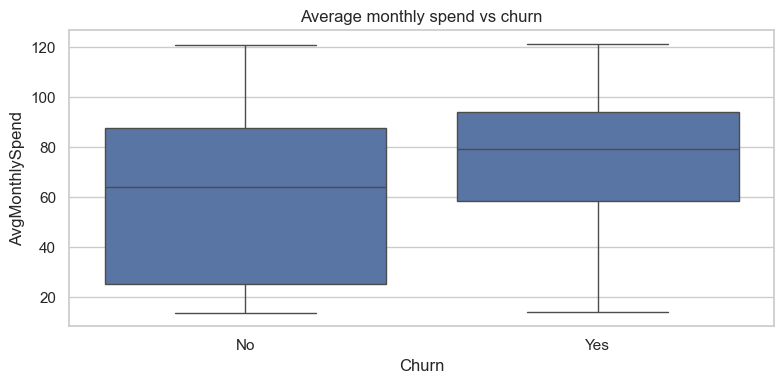

In [24]:
sns.boxplot(x="Churn", y="AvgMonthlySpend", data=df)
plt.title("Average monthly spend vs churn")
plt.tight_layout()
plt.show()


## 4. Modeling setup

**Target:** `Churn` maps to **0 = stay**, **1 = churn** (`prepare_modeling_xy`).

**Column types:** Categorical columns (text, categories) need **one-hot encoding**; numeric columns are **standardized** so penalties and distance-based behavior are not dominated by large-scale features (for example total charges versus 0 or 1 flags).

**Preprocessing fit:** I `fit_transform` on the **full** `X` below only to inspect shape and NaNs. For **unbiased** evaluation, the train or test split ensures test rows are not used to fit the preprocessor in the actual training pipelines; those pipelines refit on `X_train` only.

**Train or test split:** **80% / 20%**, **stratified** on `y` so both sets have similar churn rate, which matters when the positive class is a minority.


In [25]:
X, y = prepare_modeling_xy(df)
X.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure_group,TotalServices,AvgMonthlySpend
0,Female,0,Yes,No,1,0,0,DSL,0,1,...,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,0-12,1,29.850000
1,Male,0,No,No,34,1,0,DSL,1,0,...,0,0,One year,No,Mailed check,56.95,1889.50,24-48,3,55.573529
2,Male,0,No,No,2,1,0,DSL,1,1,...,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,0-12,3,54.075000
3,Male,0,No,No,45,0,0,DSL,1,0,...,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,24-48,3,40.905556
4,Female,0,No,No,2,1,0,Fiber optic,0,0,...,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,0-12,1,75.825000


In [26]:
categorical_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object", "string", "category"]).columns.tolist()
print("Categorical features:", categorical_cols)
print("Numerical features:", numerical_cols)
print("Number of categorical:", len(categorical_cols))
print("Number of numerical:", len(numerical_cols))


Categorical features: ['gender', 'Partner', 'Dependents', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']
Numerical features: ['SeniorCitizen', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 'AvgMonthlySpend']
Number of categorical: 8
Number of numerical: 14


### One-hot encoding and scaling (`build_preprocessor`)

**StandardScaler** on numeric features: zero mean, unit variance per column (after fitting on training data inside each pipeline).

**OneHotEncoder** on categoricals: one binary column per category (with `handle_unknown="ignore"` for unseen categories at prediction time).

The matrix may be **sparse**; `X_processed[:5]` shows a small slice of the transformed feature space.


In [27]:
preprocessor = build_preprocessor(X)
X_processed = preprocessor.fit_transform(X)
print(type(X_processed))
print("Original shape:", X.shape, "Processed shape:", X_processed.shape)


<class 'numpy.ndarray'>
Original shape: (7010, 22) Processed shape: (7010, 36)


In [28]:
X_processed[:5]


array([[-0.44092098, -1.28556609, -3.05103647, -0.85665687, -0.63514046,
         1.37503514, -0.72565001, -0.64067369, -0.79220137, -0.79889501,
        -1.16552254, -0.99728422, -1.15035432, -1.16168769,  1.        ,
         0.        ,  0.        ,  1.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         1.        ,  0.        ,  1.        ,  0.        ,  0.        ,
         0.        ],
       [-0.44092098,  0.06034582,  0.32775747, -0.85665687,  1.57445489,
        -0.72725414,  1.3780748 , -0.64067369, -0.79220137, -0.79889501,
        -0.26407097, -0.17684767, -0.17990077, -0.30886791,  0.        ,
         1.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.     

In [29]:
print("Any NaN after preprocessing:", np.isnan(X_processed).sum())


Any NaN after preprocessing: 0


### Stratified train and test split (`train_test_prepare`)

**Why stratify?** Keeps churn **prevalence** similar in train and test so metrics reflect generalization, not a lucky split.

I print label proportions to verify.


In [30]:
X_train, X_test, y_train, y_test = train_test_prepare(X, y)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Train churn distribution:")
print(y_train.value_counts(normalize=True))
print("\nTest churn distribution:")
print(y_test.value_counts(normalize=True))


Training set size: (5608, 22)
Testing set size: (1402, 22)
Train churn distribution:
Churn
0    0.735021
1    0.264979
Name: proportion, dtype: float64

Test churn distribution:
Churn
0    0.735378
1    0.264622
Name: proportion, dtype: float64


### Evaluation metrics (how to read results)

| Metric | Meaning | When it matters |
|--------|---------|-----------------|
| **Accuracy** | Fraction of correct predictions | Misleading if churn is imbalanced |
| **Precision** | Of predicted churns, how many truly churned | Costly false alarms (for example unnecessary discounts) |
| **Recall** | Of actual churners, how many I caught | Missing churners (lost revenue) |
| **F1** | Harmonic mean of precision and recall | Balance when both errors matter |
| **ROC-AUC** | Ability to rank positives above negatives (threshold-free) | **Ranking** customers for outreach; **0.7+** is often useful, **0.8+** strong for many tabular problems |

For retention, **probability** (score) is often more useful than a single threshold, because marketing can **prioritize** the top decile of risk.


## 5. Logistic regression (baseline)

**Why start with logistic regression?** **Interpretable** coefficients (log-odds), fast to train, strong baseline on tabular data. **`logistic_regression_pipeline()`** in `src.train_model` wraps the same preprocessor pattern as other models.

**Confusion matrix:** Rows are true class, columns are predicted. **Classification report:** precision, recall, F1 per class.

I report **ROC-AUC** on **predicted probabilities** of class 1 (churn), consistent with ranking use cases. The **ROC curve** below plots the true positive rate versus false positive rate across thresholds.


In [31]:
log_model = logistic_regression_pipeline(X_train)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)


In [32]:
print(confusion_matrix(y_test, y_pred))


[[942  89]
 [181 190]]


In [33]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1031
           1       0.68      0.51      0.58       371

    accuracy                           0.81      1402
   macro avg       0.76      0.71      0.73      1402
weighted avg       0.80      0.81      0.80      1402



In [34]:
accuracy = accuracy_score(y_test, y_pred)
y_prob = log_model.predict_proba(X_test)[:, 1]
roc_score = roc_auc_score(y_test, y_prob)
print("Model evaluation summary")
print("------------------------")
print("Accuracy:", accuracy)
print("ROC-AUC:", roc_score)


Model evaluation summary
------------------------
Accuracy: 0.8074179743223966
ROC-AUC: 0.8467010543763284


### ROC curve (test set)

The ROC curve visualizes tradeoffs between true positives and false positives at different thresholds. The area under the curve matches the ROC-AUC score already reported.


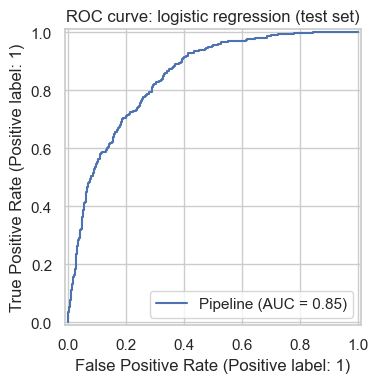

In [35]:
RocCurveDisplay.from_estimator(log_model, X_test, y_test)
plt.title("ROC curve: logistic regression (test set)")
plt.tight_layout()
plt.show()


## SHAP explainability (logistic regression)

Install SHAP once if needed: `pip install shap` (also listed in `requirements.txt`).

The following cells use the **fitted** logistic pipeline: I extract the inner estimator and the **fitted** preprocessor, transform `X_test`, and attach **human-readable column names** (same as the logistic coefficient table) so SHAP plots label features clearly. SHAP values use **100 rows** for speed.


In [36]:
%pip install shap


Note: you may need to restart the kernel to use updated packages.


In [37]:
import shap


d:\customer-churn-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [38]:
model = log_model.named_steps["model"]
preprocessor = log_model.named_steps["preprocessor"]
feature_names = get_feature_names_after_preprocessing(preprocessor, X_train)
X_test_processed = preprocessor.transform(X_test)
import scipy.sparse as sp
if sp.issparse(X_test_processed):
    X_test_processed = X_test_processed.toarray()
X_test_shap = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index,
)


In [39]:
explainer = shap.Explainer(model, X_test_shap)
shap_values = explainer(X_test_shap.iloc[:100])


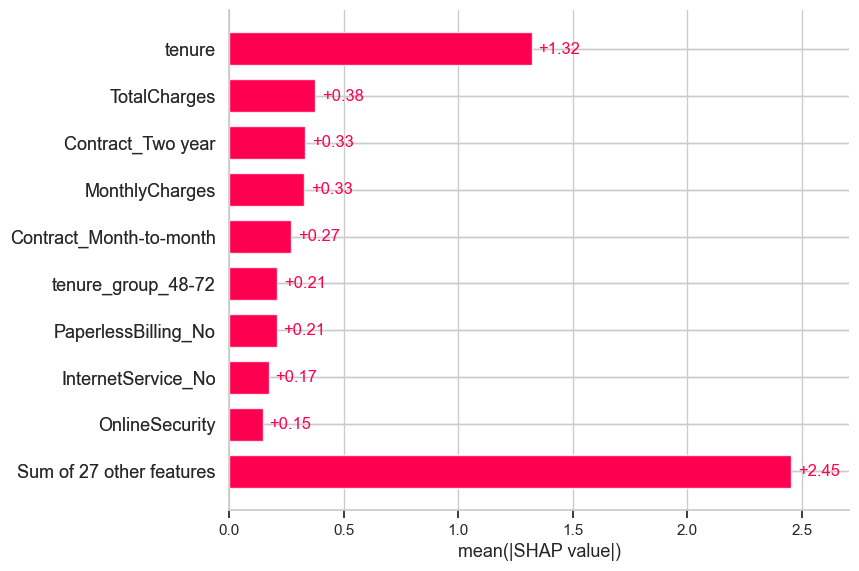

In [40]:
shap.plots.bar(shap_values)


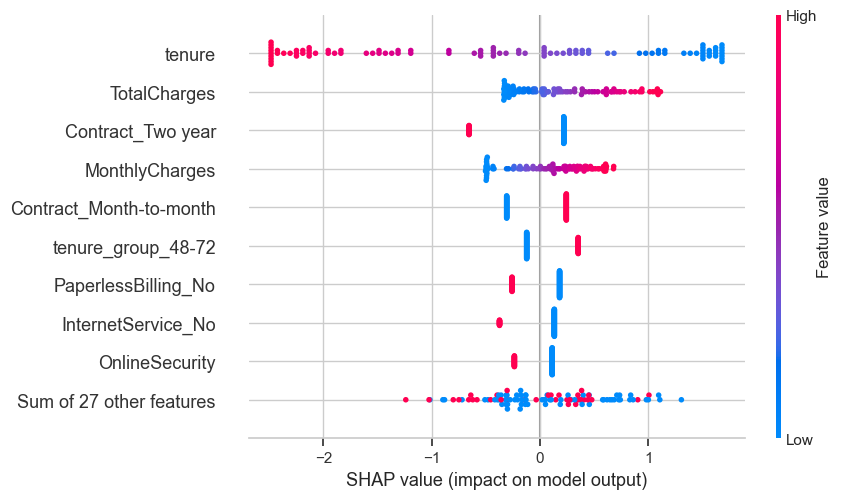

In [41]:
shap.plots.beeswarm(shap_values)


## Model explainability using SHAP

SHAP (SHapley Additive exPlanations) was used to understand how each feature contributes to customer churn prediction.

The SHAP analysis shows:
- Which features increase the probability of churn
- Which features reduce churn risk
- The most important behavioural patterns among customers

This complements the raw logistic coefficients and supports transparent, stakeholder-ready review.


## 6. Model comparison

I compare **logistic regression**, **decision tree**, **random forest**, **gradient boosting**, and **XGBoost** with the **same** preprocessing template and **held-out test set**.

**Why multiple models?** Tree ensembles capture non-linear interactions; linear models stress interpretability. **ROC-AUC** on the test set gives a **single number** to compare ranking quality across algorithms (I also persist full metrics when saving models).

The horizontal bar chart makes the ranking easy to read for stakeholders.


In [42]:
pre = build_preprocessor(X_train)
results_df = compare_models(X_train, X_test, y_train, y_test, pre)
results_df


,Model,key,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,logistic_regression,0.807418,0.681004,0.512129,0.584615,0.846701
1,Decision Tree,decision_tree,0.725392,0.481675,0.495957,0.488712,0.652800
2,Random Forest,random_forest,0.789586,0.630137,0.495957,0.555053,0.824149
3,Gradient Boosting,gradient_boosting,0.808131,0.682143,0.514825,0.586790,0.841376
4,Xgboost,xgboost,0.782454,0.611486,0.487871,0.542729,0.825146


In [43]:
results_df.sort_values(by='ROC-AUC', ascending=False)


,Model,key,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,logistic_regression,0.807418,0.681004,0.512129,0.584615,0.846701
3,Gradient Boosting,gradient_boosting,0.808131,0.682143,0.514825,0.586790,0.841376
4,Xgboost,xgboost,0.782454,0.611486,0.487871,0.542729,0.825146
2,Random Forest,random_forest,0.789586,0.630137,0.495957,0.555053,0.824149
1,Decision Tree,decision_tree,0.725392,0.481675,0.495957,0.488712,0.652800


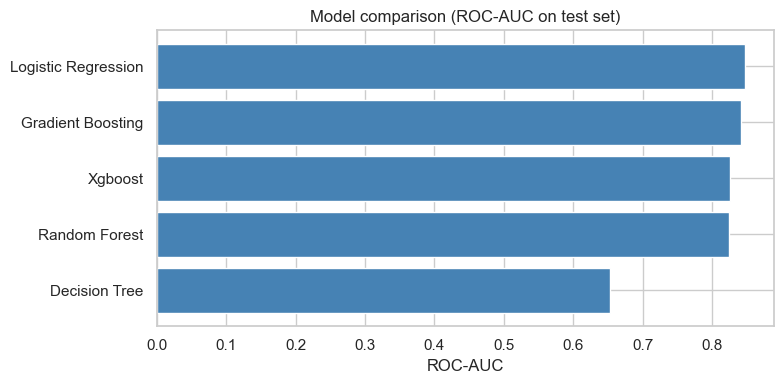

In [44]:
plot_df = results_df.sort_values('ROC-AUC', ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(plot_df["Model"], plot_df["ROC-AUC"], color="steelblue")
ax.set_xlabel("ROC-AUC")
ax.set_title("Model comparison (ROC-AUC on test set)")
plt.tight_layout()
plt.show()


## Final model selection

Based on the model comparison:

- **Logistic regression** achieved the highest ROC-AUC score on the test set
- It also showed a strong balance between precision and recall for the churn class (see the classification report and comparison table)
- The model is **interpretable** (coefficients on transformed features), which supports business and compliance discussions

Therefore **logistic regression** is selected as the **final production model** for this project baseline. Saved pipelines in `models/` include all algorithms; `metrics.json` records the best model by ROC-AUC for optional loading via `src.predict`.


## 7. Feature importance (logistic regression)

**Interpretation:** Coefficients are on the **log-odds** scale after preprocessing. **Positive** weight means higher predicted churn when that feature increases (holding others fixed in a linear sense). **Negative** means associated with staying.

One-hot columns appear as **per-category** weights versus the dropped reference category. Use **head** and **tail** to see strongest positive and negative drivers for storytelling with product and marketing teams.

**Limitation:** Coefficients show **association**, not causal proof; interventions need A/B tests.


In [45]:
fitted_pre = log_model.named_steps['preprocessor']
final_feature_names = get_feature_names_after_preprocessing(fitted_pre, X_train)
coefficients = log_model.named_steps['model'].coef_[0]
importance_df = pd.DataFrame({'Feature': final_feature_names, 'Importance': coefficients})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
importance_df.head(15)


,Feature,Importance
23,Contract_Month-to-month,0.549928
35,tenure_group_48-72,0.475246
11,TotalCharges,0.410546
10,MonthlyCharges,0.364346
21,InternetService_Fiber optic,0.217796
30,PaymentMethod_Electronic check,0.157969
13,AvgMonthlySpend,0.145001
3,MultipleLines,0.133799
0,SeniorCitizen,0.096414
8,StreamingTV,0.047125


In [46]:
importance_df.tail(15)


,Feature,Importance
20,InternetService_DSL,-0.204462
16,Partner_No,-0.228841
15,gender_Male,-0.229278
32,tenure_group_0-12,-0.236033
31,PaymentMethod_Mailed check,-0.254217
29,PaymentMethod_Credit card (automatic),-0.259232
14,gender_Female,-0.263047
17,Partner_Yes,-0.263484
2,PhoneService,-0.277023
19,Dependents_Yes,-0.329494


## 8. Persist models (`train_and_save_pipelines`)

**Production pattern:** Save the **entire** `Pipeline` (preprocessing and estimator) with **joblib** so inference uses **identical** transformations as training.

**Artifacts written to `models/`:**
- `*_pipeline.joblib` one file per algorithm
- `metrics.json` test metrics and **best model** key
- `model_comparison.csv` tabular comparison

**When to retrain:** New data, new features, or drift in churn definition. Version data and model artifacts together.


In [47]:
comparison_metrics, fitted_models = train_and_save_pipelines(
    X_train, X_test, y_train, y_test,
)
comparison_metrics


,model_key,display_name,accuracy,precision,recall,f1,roc_auc
0,logistic_regression,Logistic Regression,0.807418,0.681004,0.512129,0.584615,0.846701
3,gradient_boosting,Gradient Boosting,0.808131,0.682143,0.514825,0.586790,0.841376
4,xgboost,Xgboost,0.782454,0.611486,0.487871,0.542729,0.825146
2,random_forest,Random Forest,0.789586,0.630137,0.495957,0.555053,0.824149
1,decision_tree,Decision Tree,0.725392,0.481675,0.495957,0.488712,0.652800


## 9. Example: predicting churn for a new customer

Retention teams usually work with **risk probability**, not only a yes or no label. The code below scores **one** row from the test set using the fitted logistic pipeline and interprets a simple **0.6** threshold as high risk (you can tune this threshold from business costs).


In [48]:
sample_customer = X_test.iloc[[0]]
prob = log_model.predict_proba(sample_customer)[0][1]
print("Churn probability:", prob)
if prob > 0.6:
    print("Risk band: high (probability above 0.6)")
else:
    print("Risk band: not high at the 0.6 threshold (tune threshold for your business)")


Churn probability: 0.36659549276086933
Risk band: not high at the 0.6 threshold (tune threshold for your business)


## 10. Score rows with a saved pipeline (`src.predict`)

**`load_pipeline()`** loads the **best** model listed in `metrics.json` (with fallbacks in code if files are missing).

**`predict_proba_churn()`** returns **P(churn = 1)** per row: the second column of `predict_proba` (class 1 = churn).

**How to read the table:** Each row is a **test-set customer** (index is the row label in `X_test`). Values between **0 and 1** are **estimated probabilities**. Use them to **prioritize** outreach (for example top decile). Run **section 8** first so `models/` contains saved pipelines.


In [49]:
loaded = load_pipeline()
sample = X_test.head(10)
churn_proba = predict_proba_churn(loaded, sample)
pd.DataFrame({"churn_probability": churn_proba}, index=sample.index)


,churn_probability
743,0.366595
668,0.016347
5741,0.097178
5449,0.278274
2020,0.299640
3067,0.478272
5178,0.095671
2035,0.080207
4281,0.255889
3001,0.188131


## Key business insights

1. Customers with **month-to-month** contracts are most likely to churn
2. Customers with **higher monthly charges** show higher churn probability
3. Customers with **low tenure** are at the highest risk of churn
4. Customers **without tech support and online security** churn more often
5. **Long-term customers** (tenure greater than 24 months) have the lowest churn risk

These points align with the exploratory plots and with the logistic regression coefficients where applicable. They are **descriptive** from this dataset; **causal** claims require controlled experiments and policy review.
